# Theory Questions

In [1]:
#Question 1: What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.

In [2]:
#Ans 
#Anomaly Detection is the process of finding data points that deviate significantly from normal patterns. These unusual points are called anomalies or outliers.
#Types of Anomalies
#Point Anomaly:
#A single data point is abnormal.
#Example: ₹5,00,000 transaction when others are ₹500–₹10,000.
#Contextual Anomaly:
#A data point is abnormal only in a specific context (like time or place).
#Example: 30°C in December (normal in June).
#Collective Anomaly:
#A group of normal data points together form an abnormal pattern.
#Example: Continuous high network traffic → possible DDoS attack.
#Applications: Fraud detection, network security, health monitoring, fault detection.

In [3]:
#Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.

In [4]:
#Ans
#| **Algorithm**                                                            | **Approach**                  | **Key Idea**                                                                                                 | **Best For / Use Cases**                                                                     |
#| ------------------------------------------------------------------------ | ----------------------------- | ------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------------------------------------------- |
#| **Isolation Forest**                                                     | Tree-based ensemble method    | Isolates anomalies by randomly partitioning data; anomalies are isolated faster as they lie far from others. | High-dimensional datasets, large-scale data (e.g., fraud detection, server logs).            |
#| **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** | Density-based clustering      | Points in dense regions form clusters; points in low-density regions are anomalies.                          | Spatial or 2D/3D data, clustering with noise (e.g., GPS data, geospatial analysis).          |
#| **Local Outlier Factor (LOF)**                                           | Density-based local deviation | Measures how isolated a point is compared to its neighbors’ density.                                         | Data with varying densities, local anomaly detection (e.g., network intrusion, sensor data). |


In [5]:
#Question 3: What are the key components of a Time Series? Explain each with one example.

In [6]:
#Ans
#A Time Series is a sequence of data points recorded over time (e.g., daily temperature, monthly sales).
#It has four main components:
#Trend (T):
#The long-term upward or downward movement in data.
#Example: Company sales increasing steadily over years.
#Seasonality (S):
#Regular and repeating patterns that occur at fixed intervals (like monthly, quarterly, yearly).
#Example: Ice cream sales rising every summer and dropping in winter.
#Cyclic (C):
#Fluctuations that occur over longer, irregular periods, often linked to economic or business cycles.
#Example: Real estate prices rising and falling every few years.
#Irregular / Random (I):
#Unpredictable variations caused by random or unexpected events.
#Example: Sudden drop in airline travel due to a pandemic.

In [7]:
#Question 4: Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?

In [8]:
#Ans
#A stationary time series has constant mean, variance, and autocovariance over time.
#It can be tested using the ADF or KPSS test.
#If non-stationary, make it stationary using differencing, log transformation, or detrending.

In [9]:
#Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application

In [10]:
#Ams
#| Model       | Full Form                                 | Structure                                                                                                     | Application                                                               |
#| ----------- | ----------------------------------------- | ------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------- |
#| **AR**      | Auto-Regressive                           | Uses past values of the series.  ( X_t = c + \phi_1 X_{t-1} + \ldots + \phi_p X_{t-p} + \epsilon_t )          | For data showing correlation with its own past values.                    |
#| **MA**      | Moving Average                            | Uses past error terms.  ( X_t = c + \theta_1 \epsilon_{t-1} + \ldots + \theta_q \epsilon_{t-q} + \epsilon_t ) | For data with random shocks or noise patterns.                            |
#| **ARIMA**   | Auto-Regressive Integrated Moving Average | Combines AR and MA with differencing (I).  ( (p,d,q) ) model.                                                 | For non-stationary series (trend but no seasonality).                     |
#| **SARIMA**  | Seasonal ARIMA                            | Adds seasonal terms to ARIMA.  ( (p,d,q)(P,D,Q)_s )                                                           | For data with trend and seasonal patterns.                                |
#| **SARIMAX** | Seasonal ARIMA with eXogenous variables   | SARIMA + external predictors (X).                                                                             | For seasonal data influenced by external factors (e.g., weather, prices). |


# Practical Questions

In [12]:
#Question 6: Load a time series dataset (e.g., AirPassengers), plot the original series,and decompose it into trend, seasonality, and residual components

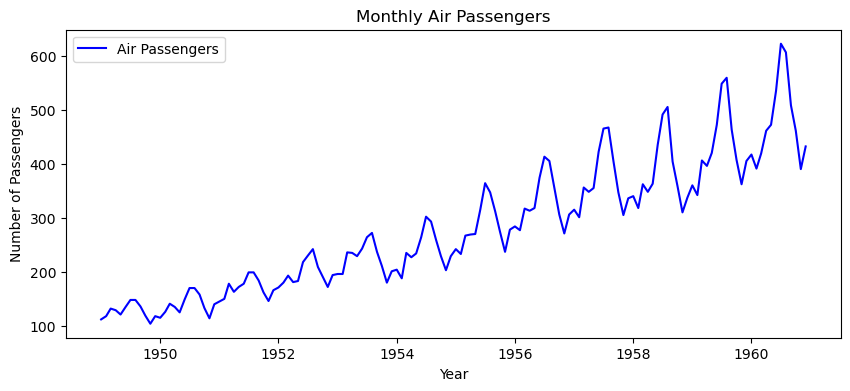

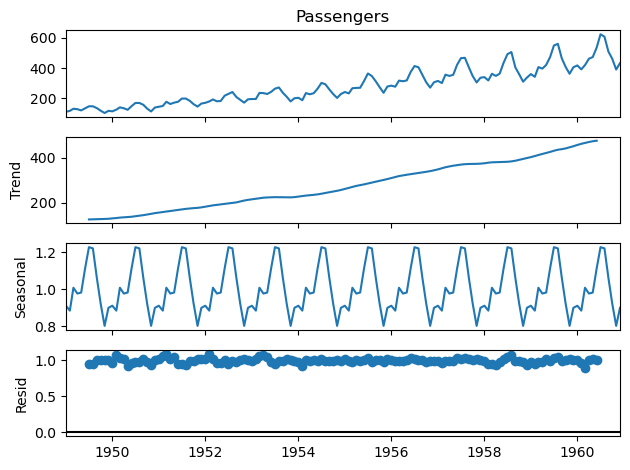

In [16]:
#Ans


import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the dataset
data = pd.read_csv("AirPassengers (1).csv")

# Rename the column for simplicity
data.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

# Convert Month to datetime and set as index
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

# Plot the original time series
plt.figure(figsize=(10,4))
plt.plot(data['Passengers'], label='Air Passengers', color='blue')
plt.title('Monthly Air Passengers')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

# Decompose the series (multiplicative model)
decomposition = seasonal_decompose(data['Passengers'], model='multiplicative', period=12)

# Plot trend, seasonality, and residuals
decomposition.plot()
plt.tight_layout()
plt.show()



In [17]:
#Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Load and sample data
data = pd.read_csv("NYC_taxi_fare_data.csv").sample(10000, random_state=42)

# Use existing numerical columns
df = data[['fare_amount', 'trip_distance', 'passenger_count', 'tip_amount', 'total_amount']].copy()
df = df.dropna()

# Fit Isolation Forest
model = IsolationForest(contamination=0.03, random_state=42)
df['anomaly'] = model.fit_predict(df)

# Visualization (2D scatter of fare vs distance)
plt.figure(figsize=(8,5))
plt.scatter(df['trip_distance'], df['fare_amount'],
            c=df['anomaly'], cmap='coolwarm', s=10)
plt.title("Isolation Forest - NYC Taxi Fare Anomalies")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.show()



C:\Users\admin\AppData\Local\Temp\ipykernel_5088\2868528968.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("NYC_taxi_fare_data.csv").sample(10000, random_state=42)


In [ ]:
#Question 8: Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results.

In [ ]:
# Question 8: Forecasting using SARIMA on AirPassengers dataset

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load dataset
data = pd.read_csv("AirPassengers (1).csv")
data.rename(columns={'#Passengers': 'Passengers'}, inplace=True)
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

# Train SARIMA model (example order values)
model = SARIMAX(data['Passengers'],
                order=(1,1,1),           # ARIMA part (p,d,q)
                seasonal_order=(1,1,1,12), # Seasonal part (P,D,Q,s)
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)

# Forecast next 12 months
forecast = results.get_forecast(steps=12)
forecast_index = pd.date_range(start=data.index[-1] + pd.offsets.MonthBegin(1),
                               periods=12, freq='MS')
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the results
plt.figure(figsize=(10,5))
plt.plot(data.index, data['Passengers'], label='Observed', color='blue')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                 color='pink', alpha=0.3)
plt.title('SARIMA Forecast: Monthly Air Passengers')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.show()


In [ ]:
#Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib

In [ ]:
#Ans
# Question 9: Anomaly Detection using Local Outlier Factor (LOF)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

# Create a synthetic numerical dataset
X, _ = make_blobs(n_samples=300, centers=[[5,5],[10,10]], cluster_std=0.8, random_state=42)

# Add some random outliers
rng = np.random.RandomState(42)
outliers = rng.uniform(low=0, high=15, size=(20, 2))
X = np.concatenate([X, outliers], axis=0)

# Apply Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X)

# Separate normal points and anomalies
normal = X[y_pred == 1]
anomalies = X[y_pred == -1]

# Visualize the results
plt.figure(figsize=(7,5))
plt.scatter(normal[:, 0], normal[:, 1], c='blue', label='Normal Data', alpha=0.6)
plt.scatter(anomalies[:, 0], anomalies[:, 1], c='red', label='Anomalies', alpha=0.8)
plt.title('Anomaly Detection using Local Outlier Factor (LOF)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


In [ ]:
#Question 10: You are working as a data scientist for a power grid monitoring company.
#Your goal is to forecast energy demand and also detect abnormal spikes or drops in
#real-time consumption data collected every 15 minutes. The dataset includes features
#like timestamp, region, weather conditions, and energy usage.
#Explain your real-time data science workflow:
#● How would you detect anomalies in this streaming data (Isolation Forest / LOF /
#DBSCAN)?
#● Which time series model would you use for short-term forecasting (ARIMA /
#SARIMA / SARIMAX)?
#● How would you validate and monitor the performance over time?
#● How would this solution help business decisions or operations?

In [ ]:
#Ans
#Anomaly Detection: Use Isolation Forest for real-time spikes/drops — fast, scalable, and works well with streaming data.
#Forecasting: Use SARIMAX for short-term energy demand — handles seasonality and weather effects.
#Validation: Monitor using RMSE (forecast) and F1-score (anomalies); retrain models regularly.
#Business Impact: Enables early fault detection, better load management, cost reduction, and reliable power supply.